In [1]:
!pip install tensorflow_cpu==2.18.0
!pip install matplotlib==3.9.2

print("==== All required libraries are installed =====")


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     - -------------------------------------- 0.3/7.8 MB 9.9 MB/s eta 0:00:01
     ----- ---------------------------------- 1.0/7.8 MB 10.5 MB/s eta 0:00:01
     ------ --------------------------------- 1.4/7.8 MB 9.5 MB/s eta 0:00:01
     ---------- ----------------------------- 2.1/7.8 MB 11.0 MB/s eta 0:00:01
     ------------- -------------------------- 2.6/7.8 MB 11.2 MB/s eta 0:00:01
     ---------------- ----------------------- 3.2/7.8 MB 11.2 MB/s eta 0:00:01
     ------------------ --------------------- 3.5/7.8 MB 11.3 MB/s eta 0:00:01
     ------------------- -------------------- 3.8/7.8 MB 10.1 MB/s eta 0:00:01
     -------------------- ------------------- 4.1/7.8 MB 9.6 MB/s eta 0:00:01
     ---------------------- ----------------- 4.3/7.8 MB 9.1 MB/s eta 0:00:01
     ----------------------- ---------------- 4.6/7.8 MB 8.9 MB/s eta 0:00:01
     ------------------------ --------------- 4.8/7.8 MB 8.8 MB/


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

In [4]:
import matplotlib.pyplot as plt

In [5]:
# import the data
from keras.datasets import mnist

# read the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [6]:
X_train.shape

(60000, 28, 28)

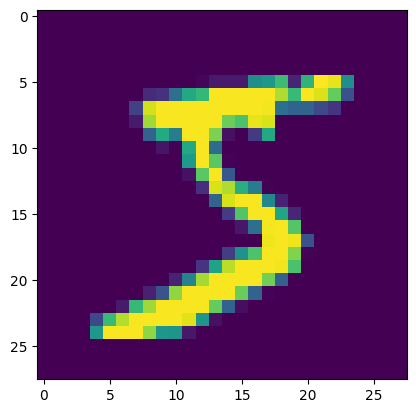

In [7]:
plt.imshow(X_train[0])

With conventional neural networks, we cannot feed in the image as input as is. So we need to flatten the images into one-dimensional vectors, each of size 1 x (28 x 28) = 1 x 784.


In [8]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images

Since pixel values can range from 0 to 255, let's normalize the vectors to be between 0 and 1.


In [9]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

Finally, before we start building our model, remember that for classification we need to divide our target variable into categories. We use the to_categorical function from the Keras Utilities package.


In [10]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


## Build a Neural Network


In [11]:
# define classification model
def classification_model():
    # create model
    
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Train and Test the Network


In [12]:
# build the model
model = classification_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/10
1875/1875 - 18s - 10ms/step - accuracy: 0.9435 - loss: 0.1837 - val_accuracy: 0.9700 - val_loss: 0.0978
Epoch 2/10
1875/1875 - 19s - 10ms/step - accuracy: 0.9755 - loss: 0.0785 - val_accuracy: 0.9737 - val_loss: 0.0879
Epoch 3/10
1875/1875 - 18s - 9ms/step - accuracy: 0.9833 - loss: 0.0525 - val_accuracy: 0.9801 - val_loss: 0.0688
Epoch 4/10
1875/1875 - 16s - 9ms/step - accuracy: 0.9869 - loss: 0.0405 - val_accuracy: 0.9781 - val_loss: 0.0802
Epoch 5/10
1875/1875 - 13s - 7ms/step - accuracy: 0.9898 - loss: 0.0321 - val_accuracy: 0.9788 - val_loss: 0.0683
Epoch 6/10
1875/1875 - 14s - 8ms/step - accuracy: 0.9915 - loss: 0.0256 - val_accuracy: 0.9690 - val_loss: 0.1284
Epoch 7/10
1875/1875 - 14s - 7ms/step - accuracy: 0.9925 - loss: 0.0233 - val_accuracy: 0.9751 - val_loss: 0.1076
Epoch 8/10
1875/1875 - 14s - 7ms/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.9820 - val_loss: 0.0800
Epoch 9/10
1875/1875 - 14s - 7ms/step - accuracy: 0.9942 - loss: 0.0186 - val_accuracy

In [13]:
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))        

Accuracy: 0.9814000129699707% 
 Error: 0.018599987030029297


Just running 10 epochs could actually take over 20 minutes. But enjoy the results as they are getting generated.


Sometimes, you cannot afford to retrain your model everytime you want to use it, especially if you are limited on computational resources and training your model can take a long time. Therefore, with the Keras library, you can save your model after training. To do that, we use the save method.


In [14]:
model.save('classification_model.keras')

Since our model contains multidimensional arrays of data, then models are usually saved as .keras files.


When you are ready to use your model again, you use the load_model function from <strong>keras.saving</strong>.


In [15]:
pretrained_model = keras.saving.load_model('classification_model.keras')